# Strong heuristic local executor test

This notebook checks the model-based local executor that converts the upper bias matrix `B[gNB, slice]` into discrete A3 offsets. It tests direct synthetic cases first, then runs one small `GlobalPPO3GNBEnv` step to verify the integration path.

In [1]:
import os
import sys
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-chech")

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from strong_heuristic_local_executor import (
    OFFSET_SET_DB,
    evaluate_candidate_offset,
    strong_heuristic_local_executor,
)

SLICE_TYPES = ("eMBB", "URLLC", "mMTC")
NEIGHBORS = {0: [1, 2], 1: [0, 2], 2: [0, 1]}
np.set_printoptions(precision=3, suppress=True)

## Synthetic input builder

In [2]:
def base_inputs():
    # Three eMBB UEs start on gNB0 near the gNB0/gNB1 boundary.
    # Neighbor gNB1 is slightly stronger, so negative offsets should make HO feasible.
    return {
        "B": np.zeros((3, 3), dtype=float),
        "prev_offsets": np.zeros((3, 3), dtype=float),
        "ue_slice": np.asarray(["eMBB", "eMBB", "eMBB", "URLLC", "mMTC"], dtype=object),
        "ue_serving_gnb": np.asarray([0, 0, 0, 1, 2], dtype=int),
        "rsrp_matrix": np.asarray(
            [
                [-82.0, -80.4, -96.0],
                [-83.0, -81.5, -97.0],
                [-81.0, -80.1, -95.5],
                [-88.0, -76.0, -84.0],
                [-90.0, -86.0, -78.0],
            ],
            dtype=float,
        ),
        "neighbor_graph": NEIGHBORS,
        "load": np.asarray(
            [
                [0.92, 0.25, 0.20],
                [0.40, 0.35, 0.30],
                [0.30, 0.30, 0.45],
            ],
            dtype=float,
        ),
        "sla_violation": np.zeros((3, 3), dtype=float),
        "ho_failure_ratio": np.zeros((3, 3), dtype=float),
        "pingpong_ratio": np.zeros((3, 3), dtype=float),
    }


def run_case(name, mutate):
    kwargs = base_inputs()
    mutate(kwargs)
    offsets, debug = strong_heuristic_local_executor(
        **kwargs,
        hysteresis_db=1.0,
        l_safe=0.85,
        slice_types=SLICE_TYPES,
        return_debug=True,
    )
    return name, kwargs, offsets, debug


def candidate_table(debug, gnb_idx=0, slice_idx=0):
    rows = debug[(gnb_idx, slice_idx)]["candidates"]
    return pd.DataFrame(rows).sort_values("candidate_offset_db").reset_index(drop=True)

## Case sweep

The important read is: negative offset means easier handover/offload; positive offset means harder handover/retain.

In [3]:
cases = [
    run_case("offload feasible", lambda k: k["B"].__setitem__((0, 0), -1.0)),
    run_case("retain/protect", lambda k: k["B"].__setitem__((0, 0), +1.0)),
    run_case(
        "offload but target overloaded",
        lambda k: (k["B"].__setitem__((0, 0), -1.0), k["load"].__setitem__((1, 0), 1.00)),
    ),
    run_case(
        "offload but high HF/PP risk",
        lambda k: (
            k["B"].__setitem__((0, 0), -1.0),
            k["ho_failure_ratio"].__setitem__((0, 0), 0.50),
            k["pingpong_ratio"].__setitem__((0, 0), 0.35),
        ),
    ),
    run_case(
        "no UEs in selected slice",
        lambda k: (k["B"].__setitem__((0, 1), -1.0), k["prev_offsets"].__setitem__((0, 1), 4.0)),
    ),
]

summary_rows = []
for name, kwargs, offsets, debug in cases:
    gnb_idx, slice_idx = (0, 1) if name == "no UEs in selected slice" else (0, 0)
    selected = debug[(gnb_idx, slice_idx)]
    summary_rows.append(
        {
            "case": name,
            "selected_gNB": gnb_idx,
            "selected_slice": SLICE_TYPES[slice_idx],
            "bias": kwargs["B"][gnb_idx, slice_idx],
            "selected_offset_db": selected["selected_offset_db"],
            "selected_score": selected["selected_score"],
            "load_g0_slice": kwargs["load"][gnb_idx, slice_idx],
            "load_g1_slice": kwargs["load"][1, slice_idx],
            "hf_ratio": kwargs["ho_failure_ratio"][gnb_idx, slice_idx],
            "pp_ratio": kwargs["pingpong_ratio"][gnb_idx, slice_idx],
        }
    )

summary = pd.DataFrame(summary_rows)
display(summary)

,case,selected_gNB,selected_slice,bias,selected_offset_db,selected_score,load_g0_slice,load_g1_slice,hf_ratio,pp_ratio
0,offload feasible,0,eMBB,-1.0,-6.0,1.500000,0.92,0.40,0.0,0.00
1,retain/protect,0,eMBB,1.0,6.0,0.300000,0.92,0.40,0.0,0.00
2,offload but target overloaded,0,eMBB,-1.0,-6.0,1.200000,0.92,1.00,0.0,0.00
3,offload but high HF/PP risk,0,eMBB,-1.0,0.0,0.800000,0.92,0.40,0.5,0.35
4,no UEs in selected slice,0,URLLC,-1.0,0.0,-0.266667,0.25,0.35,0.0,0.00


## Candidate score details for one gNB-slice

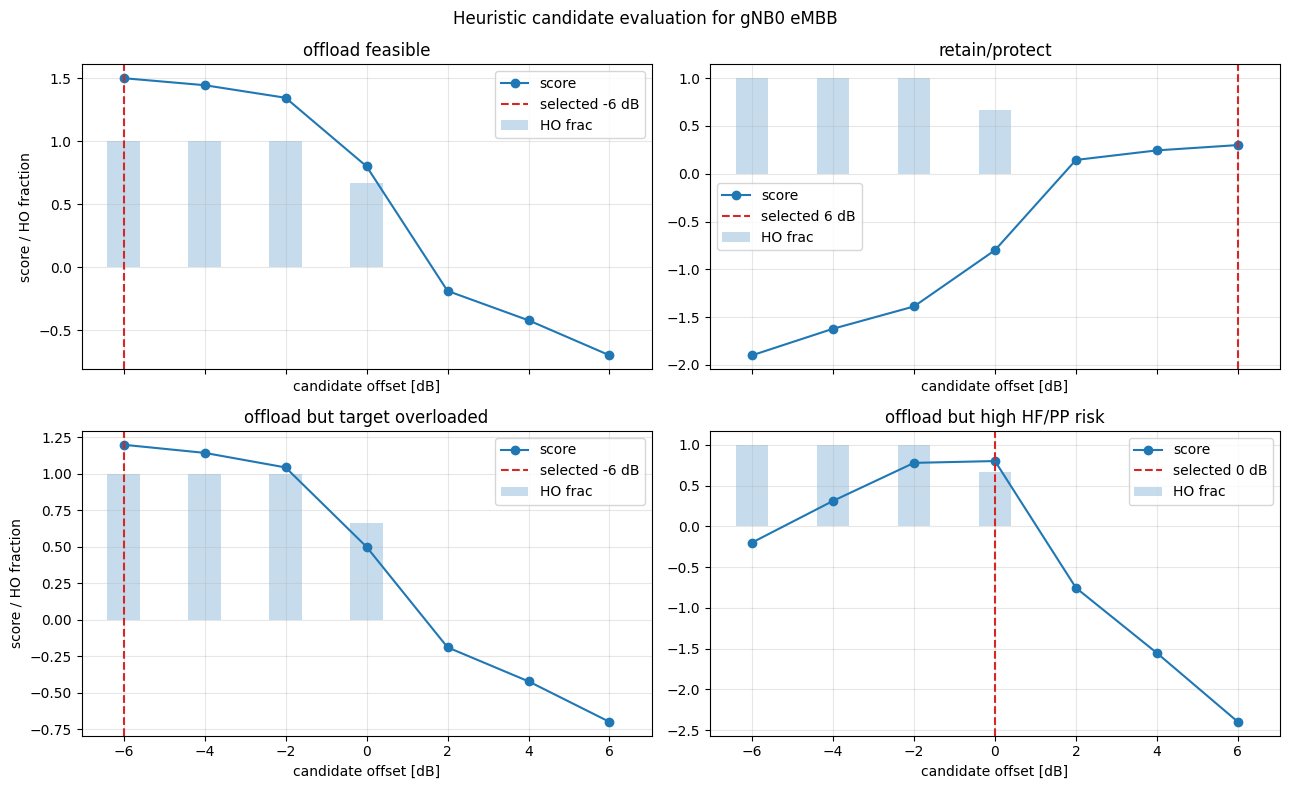

,candidate_offset_db,score,n_ues,n_predicted_handovers,ho_frac,a_bias,a_handover,a_sla,r_risk,r_target,r_osc
0,-6.0,1.500000,3.0,3.0,1.000000,1.000000,1.000000,0.0,0.0,0.0,1.000000
1,-4.0,1.444444,3.0,3.0,1.000000,0.666667,1.000000,0.0,0.0,0.0,0.444444
2,-2.0,1.344444,3.0,3.0,1.000000,0.333333,1.000000,0.0,0.0,0.0,0.111111
3,0.0,0.800000,3.0,2.0,0.666667,-0.000000,0.666667,0.0,0.0,0.0,0.000000
4,2.0,-0.188889,3.0,0.0,0.000000,-0.333333,0.000000,0.0,0.0,0.0,0.111111
5,4.0,-0.422222,3.0,0.0,0.000000,-0.666667,0.000000,0.0,0.0,0.0,0.444444
6,6.0,-0.700000,3.0,0.0,0.000000,-1.000000,0.000000,0.0,0.0,0.0,1.000000


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)
axes = axes.ravel()

plot_cases = cases[:4]
for ax, (name, kwargs, offsets, debug) in zip(axes, plot_cases):
    table = candidate_table(debug, 0, 0)
    selected = debug[(0, 0)]["selected_offset_db"]
    ax.plot(table["candidate_offset_db"], table["score"], marker="o", label="score")
    ax.bar(table["candidate_offset_db"], table["ho_frac"], width=0.8, alpha=0.25, label="HO frac")
    ax.axvline(selected, color="tab:red", linestyle="--", label=f"selected {selected:g} dB")
    ax.set_title(name)
    ax.set_xlabel("candidate offset [dB]")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best")

axes[0].set_ylabel("score / HO fraction")
axes[2].set_ylabel("score / HO fraction")
fig.suptitle("Heuristic candidate evaluation for gNB0 eMBB")
fig.tight_layout()
plt.show()

display(candidate_table(cases[0][3], 0, 0)[[
    "candidate_offset_db", "score", "n_ues", "n_predicted_handovers", "ho_frac",
    "a_bias", "a_handover", "a_sla", "r_risk", "r_target", "r_osc"
]])

## Offset matrices

Each matrix is `[gNB, slice]`. Values are A3 offsets in dB.

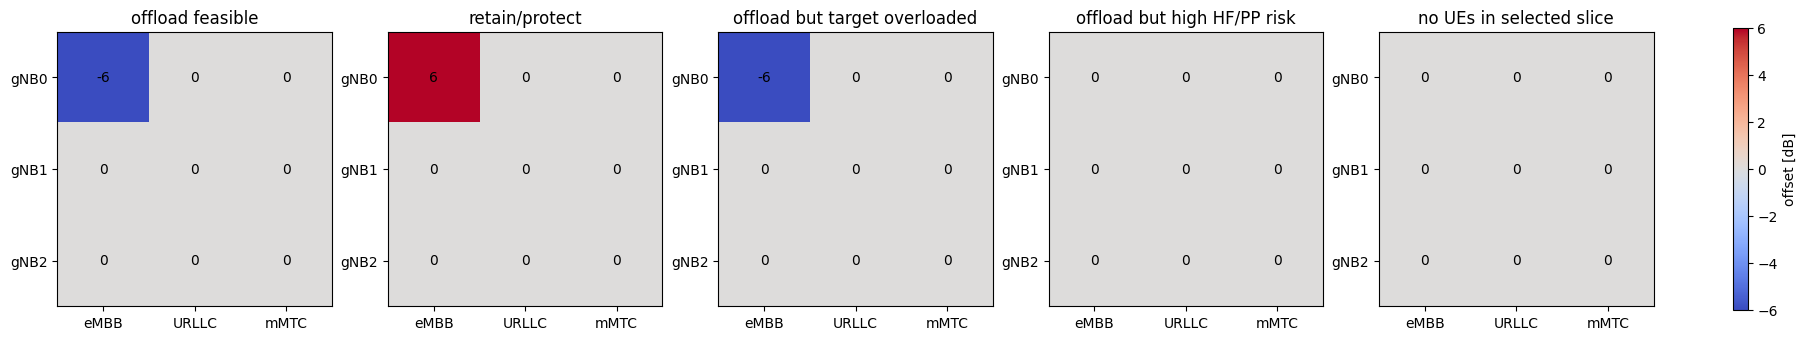

In [5]:
fig, axes = plt.subplots(1, len(cases), figsize=(18, 3.6), constrained_layout=True)
for ax, (name, kwargs, offsets, debug) in zip(axes, cases):
    im = ax.imshow(offsets, vmin=-6, vmax=6, cmap="coolwarm")
    ax.set_title(name)
    ax.set_xticks(range(3), SLICE_TYPES)
    ax.set_yticks(range(3), [f"gNB{i}" for i in range(3)])
    for i in range(3):
        for s in range(3):
            ax.text(s, i, f"{offsets[i, s]:.0f}", ha="center", va="center", color="black")
fig.colorbar(im, ax=axes, shrink=0.8, label="offset [dB]")
plt.show()

## Integration smoke with `GlobalPPO3GNBEnv`

This checks that the upper environment can call the strong heuristic, apply the offsets to the base A3 logic, and expose debug information in `info`.

In [6]:
from global_ppo_3gnb_env import GlobalPPO3GNBEnv

env = GlobalPPO3GNBEnv(
    global_steps_per_episode=1,
    local_steps_per_global=1,
    scenario_mode="random",
    slice_types=SLICE_TYPES,
    directional_global_action=False,
    terminal_reward_only=False,
)

obs, info0 = env.reset(seed=7)
action_bias = np.asarray([
    -1.0, 0.0, 0.0,
    +0.5, 0.0, 0.0,
     0.0, 0.0, 0.0,
], dtype=np.float32)
obs, reward, terminated, truncated, info = env.step(action_bias)

print("reward:", reward)
print("terminated:", terminated, "truncated:", truncated)
print("bias matrix:\n", info["bias_matrix"])
print("strong offsets [dB]:\n", info["strong_local_offsets"])
print("load matrix:\n", info["load_matrix"])
print("SLA matrix:\n", info["sla_matrix"])

valid_offsets = set(np.unique(info["strong_local_offsets"])).issubset(set(OFFSET_SET_DB))
print("valid discrete offsets:", valid_offsets)
assert valid_offsets

live_debug = info["strong_local_offset_debug"]
live_table = pd.DataFrame(live_debug[(0, 0)]["candidates"])
display(live_table[["candidate_offset_db", "score", "n_ues", "n_predicted_handovers", "ho_frac", "r_target", "r_risk", "r_osc"]])

reward: -0.3057696669554084
terminated: False truncated: True
bias matrix:
 [[-1.   0.   0. ]
 [ 0.5  0.   0. ]
 [ 0.   0.   0. ]]
strong offsets [dB]:
 [[-6.  0.  0.]
 [ 4.  0.  0.]
 [-4.  0.  0.]]
load matrix:
 [[0.5  0.36 0.14]
 [0.18 0.6  0.22]
 [0.44 0.32 0.24]]
SLA matrix:
 [[0.827 0.    0.   ]
 [0.887 0.    0.   ]
 [0.91  0.    0.   ]]
valid discrete offsets: True


,candidate_offset_db,score,n_ues,n_predicted_handovers,ho_frac,r_target,r_risk,r_osc
0,-6.0,2.100000,3.0,2.0,0.666667,0.0,0.0,1.000000
1,-4.0,2.044444,3.0,2.0,0.666667,0.0,0.0,0.444444
2,-2.0,1.944444,3.0,2.0,0.666667,0.0,0.0,0.111111
3,0.0,0.000000,3.0,0.0,0.000000,0.0,0.0,0.000000
4,2.0,-0.188889,3.0,0.0,0.000000,0.0,0.0,0.111111
5,4.0,-0.422222,3.0,0.0,0.000000,0.0,0.0,0.444444
6,6.0,-0.700000,3.0,0.0,0.000000,0.0,0.0,1.000000


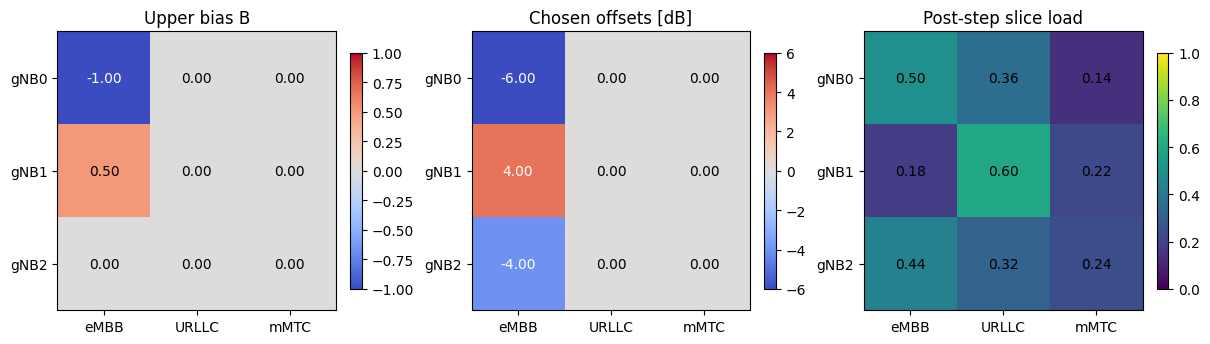

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4), constrained_layout=True)
for ax, matrix, title, cmap, vmin, vmax in [
    (axes[0], info["bias_matrix"], "Upper bias B", "coolwarm", -1, 1),
    (axes[1], info["strong_local_offsets"], "Chosen offsets [dB]", "coolwarm", -6, 6),
    (axes[2], info["load_matrix"], "Post-step slice load", "viridis", 0, 1),
]:
    im = ax.imshow(matrix, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.set_xticks(range(3), SLICE_TYPES)
    ax.set_yticks(range(3), [f"gNB{i}" for i in range(3)])
    for i in range(3):
        for s in range(3):
            ax.text(s, i, f"{matrix[i, s]:.2f}", ha="center", va="center", color="white" if abs(matrix[i, s]) > 0.6 else "black")
    fig.colorbar(im, ax=ax, shrink=0.75)
plt.show()